# Lecture Week 3: Data Visualization (Seaborn)

In [2]:
import pandas as pd
import seaborn as sns

## Get the data

In [4]:
mortality_data = pd.read_pickle('mortality_prepped.pkl')
mortality_data.head()

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584


## General vs. specific

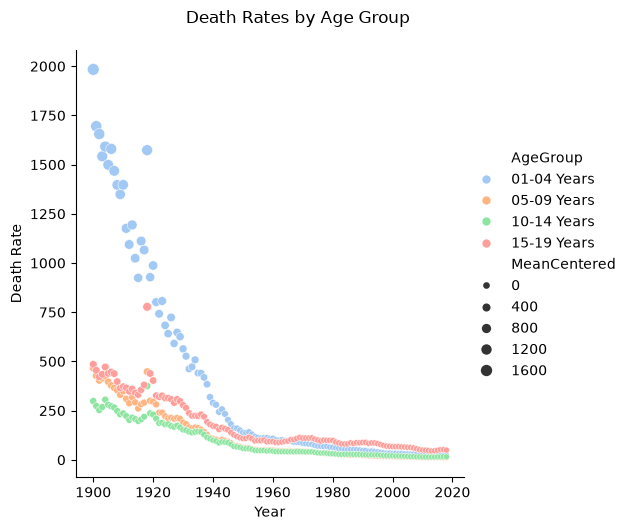

In [16]:
# Create a line plot using seaborn's relplot function
# Use the 'Year' column for the x-axis, the 'DeathRate' column for the y-axis,
# and the 'AgeGroup' column for the hue (color)
plot = sns.relplot(data=mortality_data,   x='Year',   # Scatter plot (default)
                   y='DeathRate', hue='AgeGroup', palette='pastel', size="MeanCentered") 
#To create panel: col='AgeGroup', row='AgeGroup', , size="MeanCentered"
# Add a super title (overall title) to the entire figure, rather than to an individual subplot.

plot.fig.suptitle('Death Rates by Age Group', y=1.05) 
# y controls the vertical position of the figure title.
# Set the x-axis label to 'Year' and the y-axis label to 'Death Rate'
plot.set(xlabel='Year', ylabel='Death Rate')

<img src="relplot.jpg" alt="Plot Description" width="500">

<Axes: xlabel='Year', ylabel='DeathRate'>

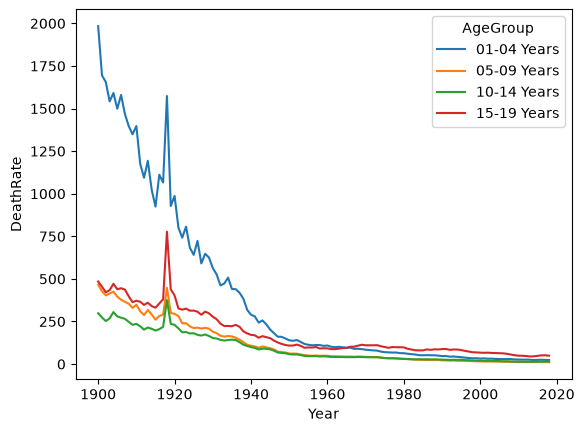

In [7]:
# Use seaborn to create a line plot with the mortality data
# Use the "lineplot" function from seaborn and pass the mortality data as the input data
# Use the "x" parameter to specify the column in the data to use for the x-axis (Year)
# Use the "y" parameter to specify the column in the data to use for the y-axis (DeathRate)
# Use the "hue" parameter to group the data by age group and display each group with a different color
sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')

<img src="compareFigAx.jpg" width="500">


```sns.lineplot()``` → Draw one line chart on one set of axes.

```sns.relplot(kind='line')``` → Create and manage the entire figure, including multiple line charts if needed using row or col.

## Basic parameters

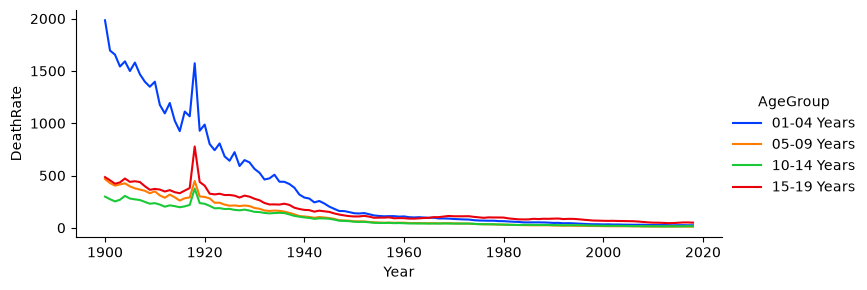

In [18]:
# Create a line plot using the seaborn relplot function, with the data as mortality_data
# Use kind='line' to specify that we want a line plot
# Set the x-axis to 'Year', the y-axis to 'DeathRate', and the hue to 'AgeGroup'
# Use the 'bright' palette to set the color scheme of the lines
# Set the height of the plot to 4 inches and the aspect ratio to 1.5
sns.relplot(data=mortality_data, kind='line', 
            x='Year', y='DeathRate', hue='AgeGroup', palette='bright',
            height=3, aspect=2.5)

# height: height of each plot in inches.
# aspect: width-to-height ratio. Width=Height×Aspect

## Subplots

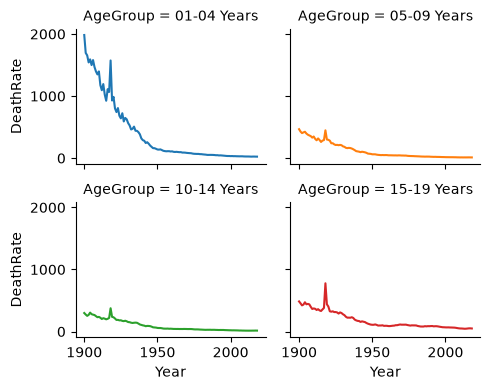

In [20]:
# plot a line plot of death rate against year for each age group
sns.relplot(data=mortality_data, 
            kind='line', x='Year', y='DeathRate', hue='AgeGroup', 
            height=2, aspect=1.25, # height parameter specifies the height of each individual subplot (facet), not the height of the entire figure.
            col='AgeGroup', col_wrap=2, # plot each age group on separate column, wrap after 2 columns
            legend=False) # remove legend

## Set the title and the x and y labels

### Specific plot (Axis-level)

[Text(0.5, 1.0, 'Deaths by Age Group'), Text(0, 0.5, 'Deaths per 100,000')]

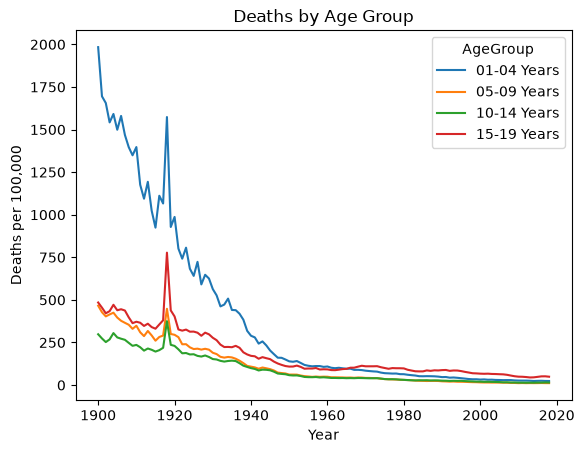

In [13]:
# Create a line plot using seaborn's lineplot function
ax = sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')
# ax is a reference to a specific plot. Without ax, you need to find the plot again.

# Set the title and y-axis label of the plot
ax.set(title='Deaths by Age Group', ylabel='Deaths per 100,000')

### General plot (Figure-level)

[[<Axes: xlabel='Year', ylabel='DeathRate'>]]


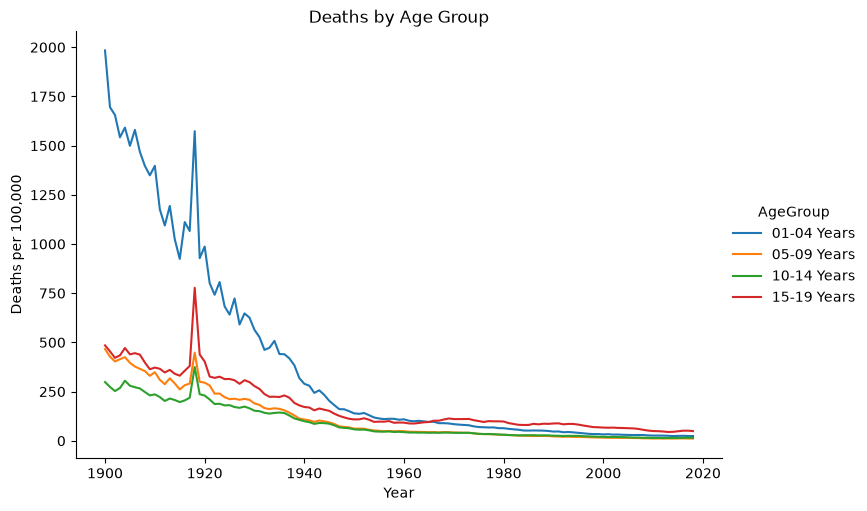

In [22]:
# create a line plot with seaborn library, using mortality_data as data source
# x-axis is 'Year', y-axis is 'DeathRate', hue is 'AgeGroup'
# set the aspect ratio of the plot to 1.5
g = sns.relplot(data=mortality_data, kind='line', #default: scatter
                x='Year', y='DeathRate', hue='AgeGroup', aspect=1.5)
print(g.axes)
# iterate over each subplot axis in the plot
for ax in g.axes.flat:
    # set the title and y-axis label for each subplot axis
    ax.set(title='Deaths by Age Group', ylabel='Deaths per 100,000')

## Set the ticks, x limits, and y limits

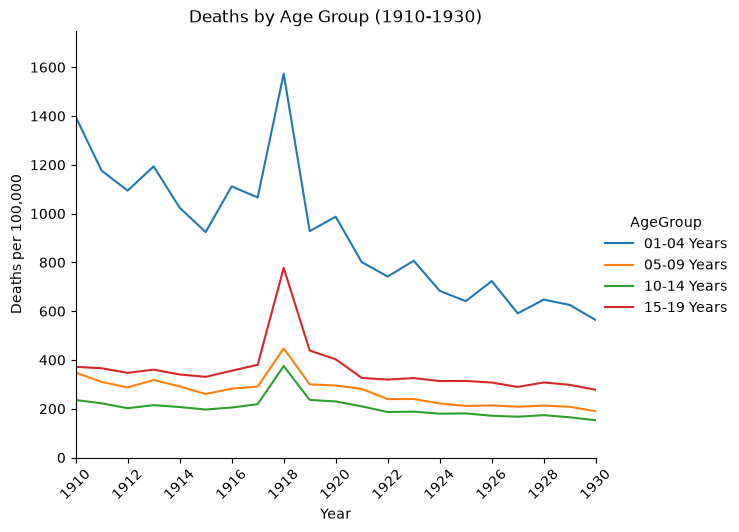

In [24]:
# Create a line plot with seaborn, with one line per age group
g = sns.relplot(data=mortality_data, kind='line',
                x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

# Set the title and y-axis label for each subplot
for ax in g.axes.flat: # g.axes gives access to all the axes inside the grid.
    # Because your subplots are arranged in rows and columns, g.axes is usually a 2D NumPy array.
    # .flat converts the 2D array into a sequence:
    # So you can easily apply the same operation to every subplot.
    ax.set(title='Deaths by Age Group (1910-1930)', ylabel='Deaths per 100,000', 
           xticks=[x for x in range(1910, 1931, 2)], 
           xlim=(1910,1930), ylim=(0,1750))

    # Rotate the x-axis labels for readability
    ax.tick_params('x', labelrotation=45)

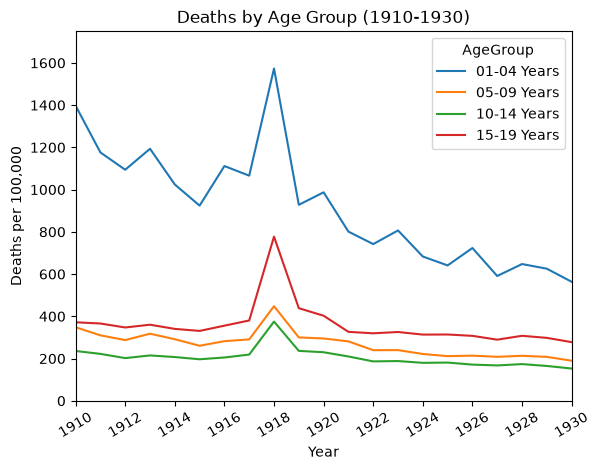

In [22]:
# Create a line plot using Seaborn with mortality_data as the data source.
# The x-axis will be Year and the y-axis will be DeathRate.
# The plot will be grouped by AgeGroup and each line will have a different color.
ax = sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')

# Set the plot title, y-axis label, and x-axis tick marks and limits.
# We are plotting data for the years 1910-1930, so we set the x-axis limits accordingly.
ax.set(title='Deaths by Age Group (1910-1930)', ylabel='Deaths per 100,000', 
      xticks=[x for x in range(1910,1931,2)], xlim=(1910,1930), ylim=(0,1750))

# Rotate the x-axis tick labels by 30 degrees to make them more readable.
ax.tick_params('x', labelrotation=30)

## Set the background style

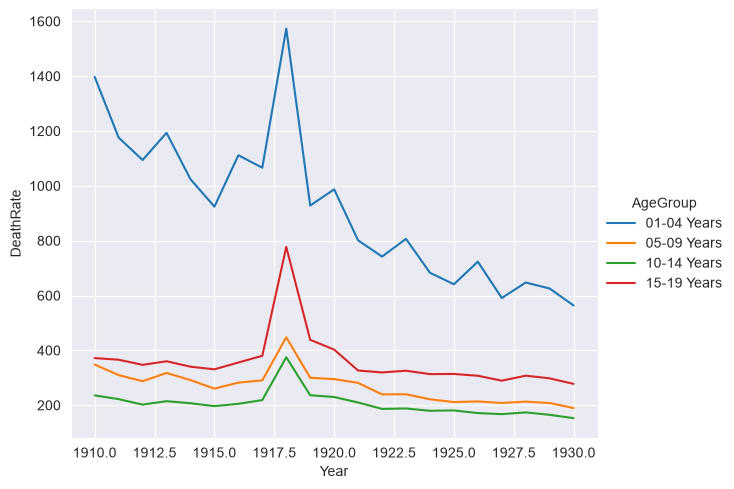

In [38]:
# set the plotting style to whitegrid
sns.set_style('darkgrid') #Darkgrid, ticks, dark, white

# create a line plot of mortality data between 1910 and 1930
# with DeathRate on the y-axis, Year on the x-axis, and AgeGroup as the hue
# set the aspect ratio to 1.25
sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
            kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

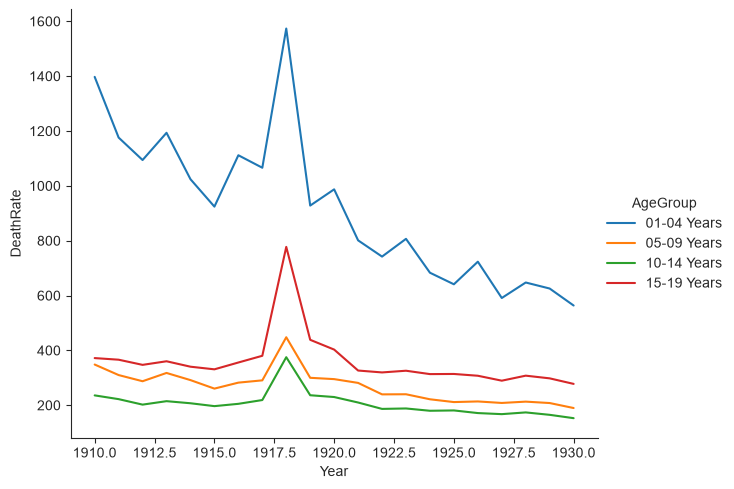

In [40]:
# Set the style to 'darkgrid'
sns.set_style('ticks')

# Create a line plot using seaborn relplot
sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)


In [26]:
# Set the plotting style to 'ticks'
sns.set_style('ticks')

## Use the set() and suptitle() methods with subplots

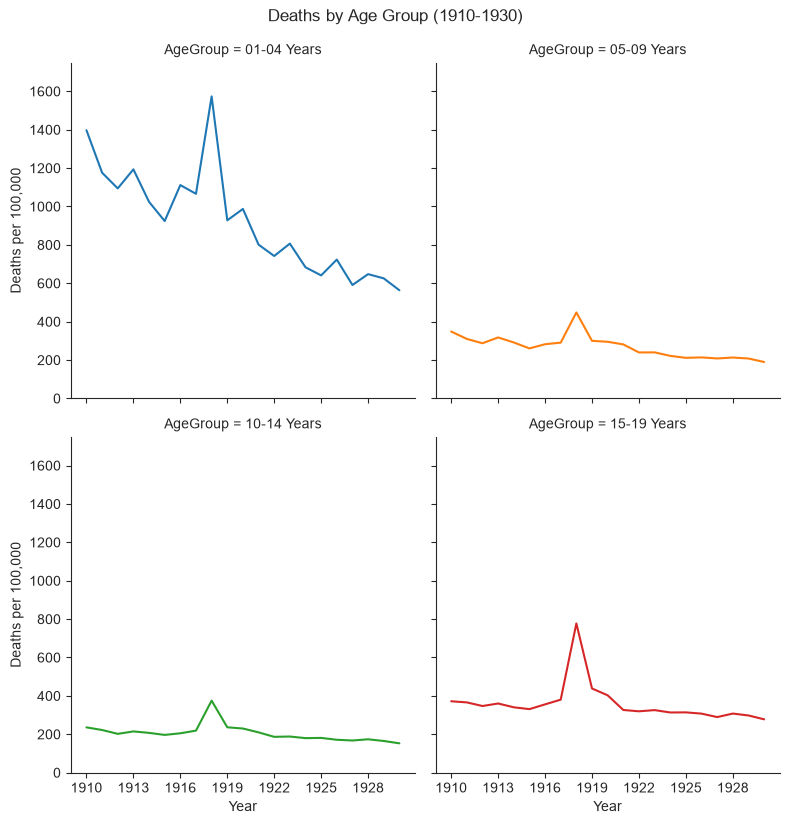

In [28]:
# create a line plot with multiple subplots, one for each age group
# only include data from 1910-1930
g = sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
                kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False,
                col='AgeGroup', col_wrap=2, height=4)

# add a title to the entire plot
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025) # g.fig.suptitle() is used to add a main title for the entire figure

# set the y-axis label and tick marks
g.set(ylabel='Deaths per 100,000', 
      xticks=[x for x in range(1910,1931,3)], 
      ylim=(0,1750))

## Save a plot to a file

### General plot

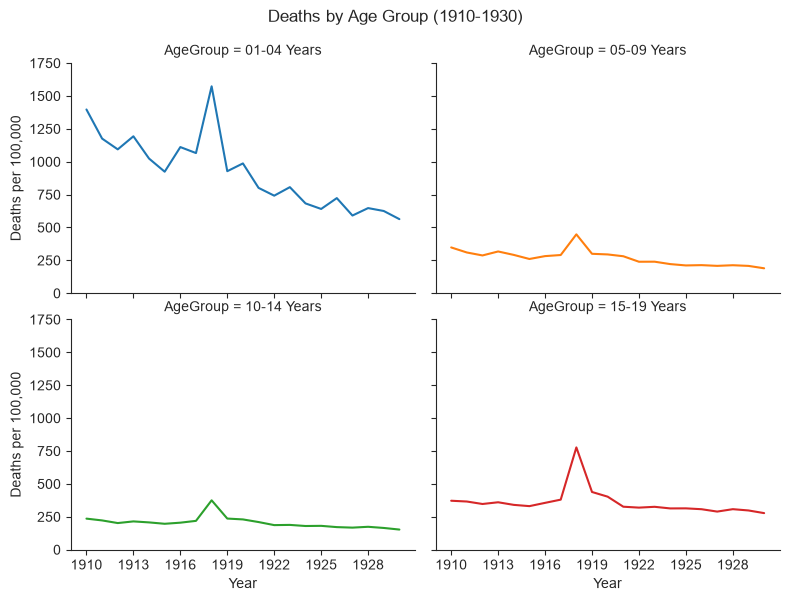

In [42]:
# create a line plot using seaborn relplot with mortality data 
# between 1910 and 1930 and with AgeGroup as hue
g = sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False,
    col='AgeGroup', col_wrap=2, height=4)

# set the super title of the plot
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)

# set the y label and x ticks for all subplots of the plot object
g.set(ylabel='Deaths per 100,000', 
      xticks=[x for x in range(1910,1931,3)], 
      ylim=(0,1750))

# adjust the bottom of the plot to fix the y-axis labels
g.fig.subplots_adjust(bottom=0.35) # to adjust the spacing around subplots inside a figure.

# save the plot as png, svg, and pdf in the current working directory
g.savefig('lineChart.png')
g.savefig('lineChart.svg')
g.savefig('figures/lineChart.pdf')


### Specific plot

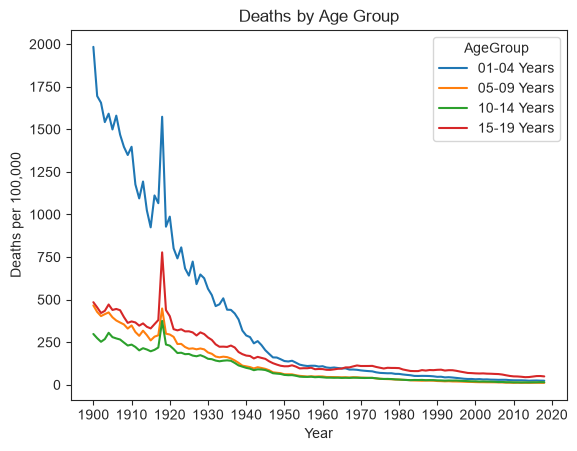

In [33]:
# Create a line plot using the mortality data, with Year on the x-axis and DeathRate on the y-axis, 
# and different line colors for each AgeGroup
ax = sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')

# Set the title, y-axis label, and x-axis tick labels
ax.set(title='Deaths by Age Group', ylabel='Deaths per 100,000', 
       xticks=[x for x in range(1900, 2021, 10)])

# Save the plot as a PNG, SVG, and PDF file
ax.get_figure().savefig('figures/lineChart.png')
ax.get_figure().savefig('figures/lineChart.svg')
ax.get_figure().savefig('figures/lineChart.pdf')
# ax.get_figure() retrieves the Figure object that contains this Axes.

## Line plots

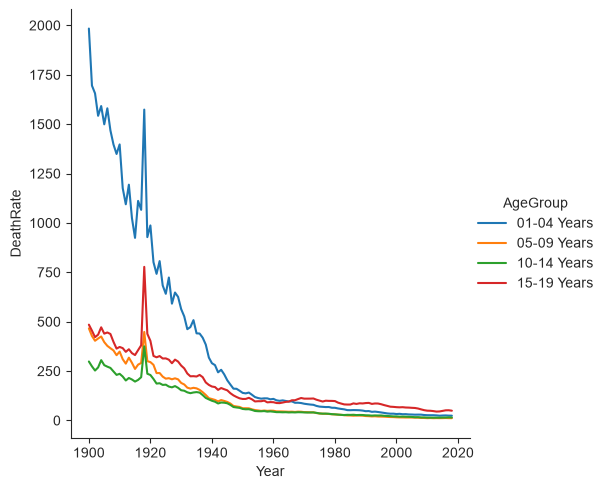

In [35]:
# Plot a line chart using seaborn relplot function
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate', hue='AgeGroup')

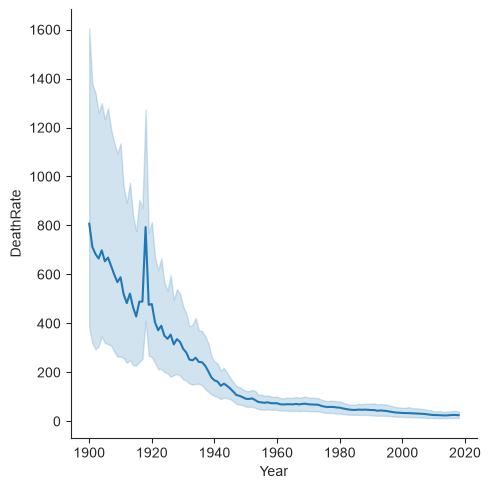

In [36]:
# create a line plot with mortality_data
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate')

## Scatter plots

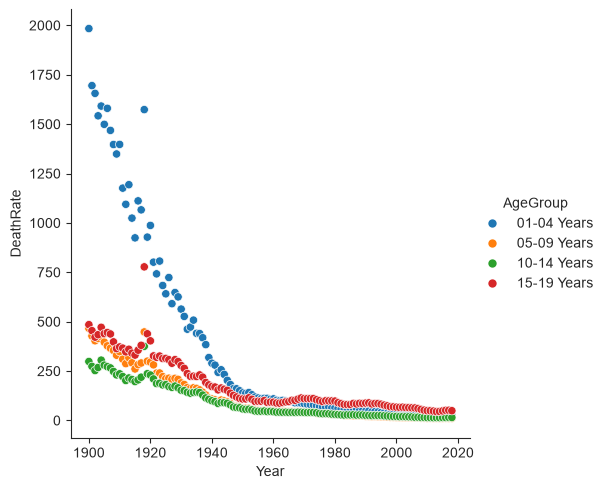

In [38]:
# create a scatter plot using Seaborn's relplot function
# data parameter specifies the data frame to use
# kind parameter specifies the type of plot to create, which is a scatter plot in this case
# x and y parameters specify the columns to use for the x and y axes, respectively
# hue parameter specifies the column to use for color grouping
sns.relplot(data=mortality_data, kind='scatter', x='Year', y='DeathRate', hue='AgeGroup')

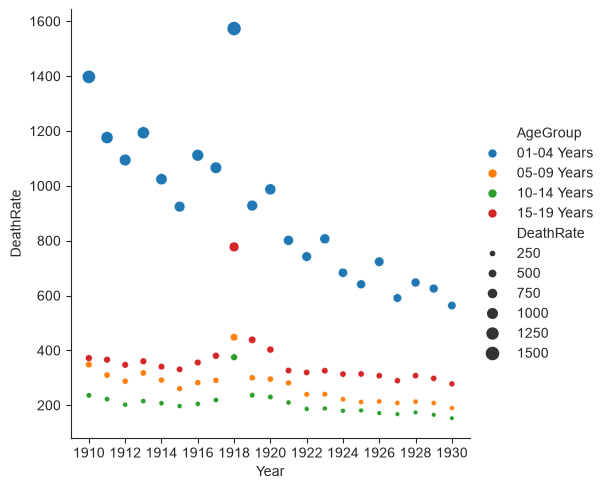

In [39]:
# create a scatter plot with markers sized by 'DeathRate'
g = sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'), 
    kind='scatter', x='Year', y='DeathRate', hue='AgeGroup', 
    size='DeathRate', sizes=(10,100))

# loop over each subplot and set the x-ticks
for ax in g.axes.flat:
    ax.set(xticks=[x for x in range(1910,1931,2)])

## Bar plots

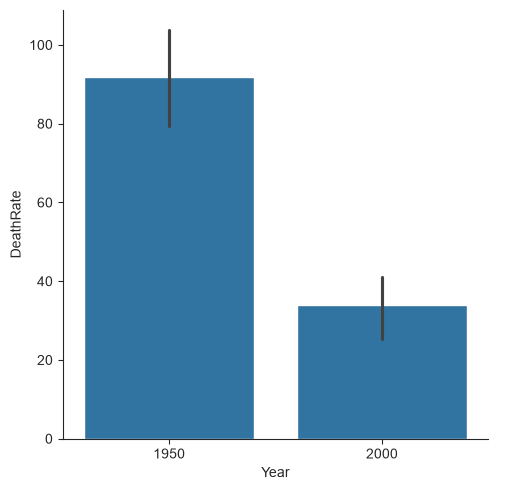

In [41]:
# create a bar plot using categorical data
# select the mortality data for years 1950 and 2000
# display the mean and confidence interval of the DeathRate using a bar chart
sns.catplot(data=mortality_data.query('Year in (1950,2000)'), 
            kind='bar', x='Year', y='DeathRate', errorbar=('ci', 50))

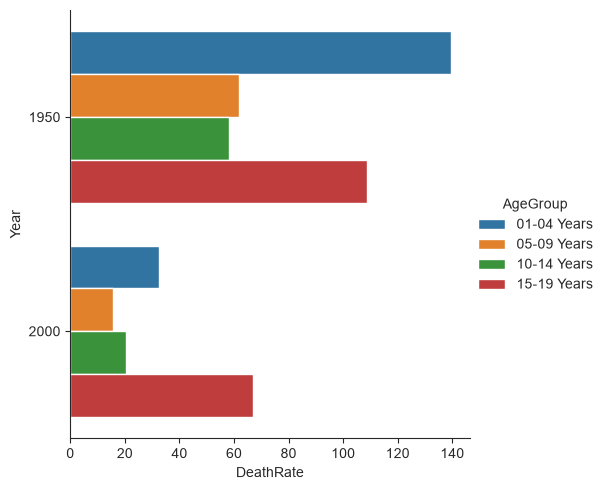

In [46]:
# create a categorical plot using seaborn, with data filtered to years 1950 and 2000
# and bar chart as the plot type
# the y-axis shows the years, x-axis shows the death rate, and bars are grouped by age group horizontally
sns.catplot(data=mortality_data.query('Year in (1950,2000)'), 
            kind='bar', x='DeathRate', y='Year', hue='AgeGroup', orient='h')


## Box plots

In [ ]:
# Create a box plot showing the distribution of death rates per year between 1915 and 1920
sns.catplot(data=mortality_data.query('Year >= 1915 and Year <= 1920'), 
            kind='box', x='Year', y='DeathRate')


In [ ]:
# Create a categorical plot with boxes showing the distribution of death rates across age groups
# The x-axis represents the death rate and the y-axis represents the age group
sns.catplot(data=mortality_data, kind='box', x='DeathRate', y='AgeGroup', orient='h')

## Histogram

In [ ]:
# create a histogram of DeathRate values
sns.displot(data=mortality_data, kind='hist', x='DeathRate')

In [ ]:
# create a histogram plot of the DeathRate column from the mortality_data DataFrame
# set the number of bins to 8
sns.displot(data=mortality_data, kind='hist', x='DeathRate', bins=8)

## KDE and ECDF plots

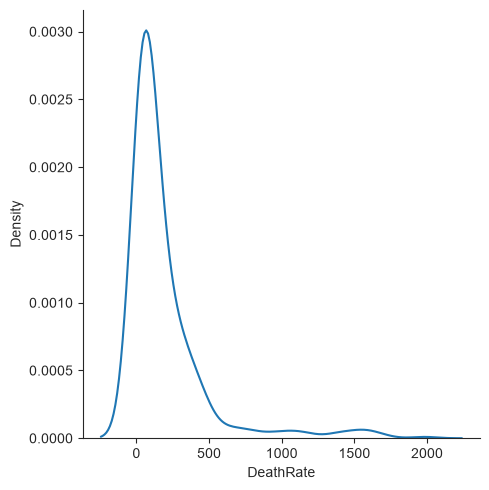

In [48]:
# Plot a kernel density estimate (KDE) of the distribution of death rates
# in mortality_data
sns.displot(data=mortality_data, kind='kde', x='DeathRate')


In [ ]:
# Plot an empirical cumulative distribution function (ECDF) of DeathRate with AgeGroup
sns.displot(data=mortality_data, kind='ecdf', x='DeathRate', hue='AgeGroup')

## Enhanced distribution plots

In [ ]:
sns.displot(data=mortality_data,              # Specify the data to use
            kind='hist',                     # Specify the type of plot
            x='DeathRate',                   # Specify the variable for the x-axis
            kde=True,                        # Enable the KDE curve on top of the histogram
            bins=8)                          # Set the number of bins to use in the histogram

In [ ]:
# Create a kernel density estimate plot of death rates, with separate curves for each age group
# The `fill` parameter fills in the area under the curve
# The `col` parameter specifies that each age group should be plotted in a separate column
# The `col_wrap` parameter specifies that there should be 2 columns of plots
# The `height` parameter sets the height of each plot
# The `legend` parameter is set to False so that the legend doesn't appear on each plot
sns.displot(data=mortality_data, kind='kde', x='DeathRate', hue='AgeGroup', 
            fill=True, col='AgeGroup', col_wrap=2, height=3, legend=False)

## Axes methods for enhancing a plot

In [ ]:
# Create a line plot using relplot
g = sns.relplot(
    data=mortality_data, 
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

# Iterate through the axes and customize each plot
for ax in g.axes.flat:
    
    # Set the title for each plot
    ax.set_title('Deaths by Age Group (2000-2016)')
    
    # Remove the x-axis label
    ax.set_xlabel('')
    
    # Set the x-axis tick marks and labels
    ax.set_xticks([x for x in range(2000,2017,2)])
    ax.set_xticklabels(['Year ' + str(x) for x in range(0,17,2)])
    
    # Rotate the x-axis tick labels
    ax.tick_params('x', labelrotation=30)
    
    # Set the y-axis label
    ax.set_ylabel('Deaths per 100,000')
    
    # Set the limits for the x and y axes
    ax.set_xlim(2000,2016)
    ax.set_ylim(0,80)

## Annotate a plot

In [ ]:
# Create a line plot showing deaths by year for each age group
ax = sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')
# Set the title of the plot
ax.set_title('Deaths by Age Group')
# Set the y-axis label
ax.set_ylabel('Deaths per 100,000')
# Add an annotation for the Spanish Flu Pandemic
ax.annotate(text='Spanish Flu Pandemic', 
    xy=(1918, 1650), xytext=(1925, 1900), 
    arrowprops=dict(facecolor='red', width=3, headwidth=12, headlength=6))

## Set color palette

In [ ]:
# Define the colors to be used in the plot
colors = ['black','red','orange','blue']
# Set the color palette of seaborn to use the defined colors
sns.set_palette(sns.color_palette(colors))
# Create a line plot of mortality data with the defined color palette
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate', hue='AgeGroup')

In [ ]:
# Set the color palette for seaborn plots to 'tab10'
sns.set_palette(sns.color_palette('tab10'))

## Axes methods for enhancing subplots

In [ ]:
# Create a line plot with multiple subplots
g = sns.relplot(
    data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False,
    col='AgeGroup', col_wrap=2, height=3, aspect=1.2)

# Set the figure title
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)

# Customize each subplot
for ax in g.axes.flat:
    ax.set_ylabel('Deaths per 100,000')
    ax.set_xticks([x for x in range(1910, 1931, 2)])
    ax.tick_params('x', labelrotation=45)


## Custom titles for subplots

In [ ]:
g = sns.relplot(
    data=mortality_data.query('Year >= 1910 and Year <= 1930'), 
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False, 
    col='AgeGroup', col_wrap=2, height=3, aspect=1.2)

# Add a title to the entire plot
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)

# Get the list of unique age groups
ageGroups = mortality_data['AgeGroup'].drop_duplicates().tolist()

# Iterate over each subplot and customize it
for index, ax in enumerate(g.axes.flat):
    ax.set_title(ageGroups[index]) # Set the title of the subplot to the age group
    ax.set_ylabel('Deaths per 100,000')
    ax.set_xticks([x for x in range(1910, 1931, 2)])
    ax.tick_params('x', labelrotation=45) # Rotate the x-axis labels for readability


## Set the size for a specific plot

In [ ]:
# import a Matplotlib module and set the figure size
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,7.5)) 
# create the line plot
sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')
# use the ax and fig objects to enhance and save the plot
ax.set(title='Deaths by Age Group (1910-1930)', 
    ylabel='Deaths per 100,000', 
    xticks=[x for x in range(1910, 1931, 2)], 
    xlim=(1910,1930), ylim=(0,1750)),
ax.tick_params('x', labelrotation=45)
fig.savefig('deaths_by_age_group_line.png')
